# Beta Bank — Customer Churn Prediction

> **Note:** Beta Bank is a fictional institution created exclusively for academic and portfolio purposes. This notebook was developed as part of a Data Science training program and is intended solely to demonstrate technical skills in machine learning and data analysis.

---

## 1. Introduction and Objective

Beta Bank is experiencing a persistent and costly problem: customer churn. Month after month, clients are quietly leaving — and research consistently shows that retaining an existing customer is significantly cheaper than acquiring a new one.

The objective of this project is to build a machine learning classification model capable of predicting whether a given customer will leave the bank in the near future. By identifying at-risk customers early, the bank can deploy targeted retention strategies before the relationship is lost.

The model is trained on historical data covering customer behavior and contract terminations. The success criterion is an **F1-score of at least 0.59** on the held-out test set. The **AUC-ROC** metric is also computed and compared against the F1-score to provide a more complete picture of model performance.

The pipeline follows these key steps:
1. Data loading and preparation
2. Class imbalance analysis and baseline modeling
3. Imbalance correction and model improvement
4. Hyperparameter optimization via `RandomizedSearchCV`
5. Final evaluation on the test set

The necessary libraries are imported below.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
from sklearn.utils import shuffle

# The import statement below will suppress deprecation warnings to keep everything "cleaner"import warnings
import warnings
warnings.filterwarnings('ignore')

## 2. Data Preparation

This step covers loading the dataset, removing columns that carry no predictive signal, handling missing values, and encoding categorical variables. Numerical features are also scaled to ensure proper model behavior.

The dataset contains **10,000 customer records** across 14 features, including demographic information, account activity, and a binary target variable (`Exited`) indicating whether the customer churned.

In [2]:
df = pd.read_csv('../data/Churn.csv')

display(df.head())
df.info()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), str(3)
memory usage: 1.2 MB


The `Tenure` column contains **909 missing values** (~9.1% of the dataset). Since this feature represents the number of years a customer has been with the bank, median imputation is applied — a robust choice that avoids skewing the distribution with extreme values.

Three columns are then dropped as they carry no predictive value for churn: `RowNumber` (a simple index), `CustomerId` (a non-informative identifier), and `Surname` (a name that provides no behavioral signal).

In [3]:
df['Tenure'].fillna(df['Tenure'].median(), inplace=True)

cols_to_remove = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(cols_to_remove, axis=1)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           9091 non-null   float64
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(3), int64(6), str(2)
memory usage: 966.1 KB


One-hot encoding is applied to the categorical features `Geography` and `Gender`. The `drop_first=True` parameter is used to avoid multicollinearity caused by the dummy variable trap — a standard best practice when working with tree-based models as well as linear ones.

In [4]:
df = pd.get_dummies(df, drop_first=True)
display(df.head())

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2.0,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1.0,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8.0,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1.0,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2.0,125510.82,1,1,1,79084.10,0,False,True,False


## 3. Data Splitting and Feature Scaling

The dataset is split into features (`X`) and the target variable (`y`), then divided into **training (80%)** and **test (20%)** sets using stratified sampling — ensuring that the class ratio is preserved in both splits.

Numerical features are standardized using `StandardScaler`, fitted **exclusively on the training set** to prevent data leakage. The same transformation is then applied to the test set.

In [5]:
x = df.drop('Exited', axis=1)
y = df['Exited']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=54321, stratify=y)

numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
scaler = StandardScaler()

scaler.fit(x_train[numeric_cols])
x_train[numeric_cols] = scaler.transform(x_train[numeric_cols])
x_test[numeric_cols] = scaler.transform(x_test[numeric_cols])

print("Size of x_train:", x_train.shape)
print("Size of x_test", x_test.shape)


Size of x_train: (8000, 11)
Size of x_test (2000, 11)


## 4. Class Imbalance Analysis and Baseline Model

Before addressing imbalance, it is essential to quantify it and understand its effect on an uncorrected model. A baseline `RandomForestClassifier` is trained without any class balancing to establish a reference point for subsequent improvements.

In [6]:
print("Class distribution in Target:")
print(y.value_counts(normalize=True))

#The initial model
model_base = RandomForestClassifier(random_state=54321)
model_base.fit(x_train, y_train)

#Predictions and metrics
preds_base = model_base.predict(x_test)
probs_base = model_base.predict_proba(x_test)[:, 1]

f1_base = f1_score(y_test, preds_base)
roc_auc_base = roc_auc_score(y_test, probs_base)

print("F1-score (base)", f1_base)
print("AUC-ROC (base)", roc_auc_base)

Class distribution in Target:
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64
F1-score (base) 0.5683229813664596
AUC-ROC (base) 0.8427395037564529


The class distribution confirms a significant imbalance: approximately **80% of customers did not churn** (`Exited = 0`) versus only **~20% who did** (`Exited = 1`).

The baseline model — trained without any correction — achieves an F1-score of **~0.568**, falling just below the project's minimum threshold of 0.59. This is a direct consequence of the class imbalance: the model is biased toward the majority class and systematically underperforms on the minority class (churned customers), which is precisely the class of interest.

The AUC-ROC of **~0.843** indicates that the model has reasonable discriminatory ability in general, but the F1-score reveals that this is not translating into reliable churn detection. Intervention is required.

## 5. Improving Model Quality: Addressing Class Imbalance

Two techniques are evaluated to correct the class imbalance:

1. **Class Weight adjustment** — penalizes errors on the minority class more heavily during training, without altering the data itself.
2. **Upsampling** — artificially increases the number of minority-class instances in the training set by replicating existing examples, giving the model more material to learn churning patterns from.

In [7]:
# CLASS WEIGHT APPROACH
model_weight = RandomForestClassifier(class_weight='balanced', random_state=54321)
model_weight.fit(x_train, y_train)
preds_weight = model_weight.predict(x_test)
print("F1-score (Class Weight)", f1_score(y_test, preds_weight))

# UPSAMPLING APPROACH
def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)

    features_upsampled, target_upsampled = shuffle(features_upsampled, target_upsampled, random_state=54321)
    return features_upsampled, target_upsampled

# In the previous code, we saw that class 0 is about four times larger than class 1, so I will repeat class 1 four times
x_upsampled, y_upsampled = upsample(x_train, y_train, 4)
model_upsample = RandomForestClassifier(random_state=54321)
model_upsample.fit(x_upsampled, y_upsampled)
preds_upsample = model_upsample.predict(x_test)

print("F1-score (UPSAMPLING)", f1_score(y_test, preds_upsample))

F1-score (Class Weight) 0.5687203791469194
F1-score (UPSAMPLING) 0.6071428571428571


The results are clear:

- **Class Weight** yielded an F1-score of ~0.569 — virtually no improvement over the uncorrected baseline. Adjusting penalties without changing the data distribution proved insufficient for this dataset.
- **Upsampling** achieved an F1-score of **~0.607**, surpassing the project's minimum target of 0.59 already at this stage.

Upsampling forces the model to encounter more varied examples of churning customers, allowing it to internalize more nuanced patterns. This approach is selected as the foundation for the final model, and hyperparameter optimization will be applied on top of it.

## 6. Hyperparameter Optimization with RandomizedSearchCV

`RandomizedSearchCV` is used to systematically search for the best hyperparameter configuration for the Random Forest model. Rather than exhaustively testing every combination (as in Grid Search), it samples 20 random configurations from the defined parameter space and evaluates each using 5-fold cross-validation on the upsampled training data — totaling **100 training runs**.

This approach is both efficient and statistically robust: it explores a broad parameter space while using cross-validation to guard against overfitting to any particular data split.

In [8]:
# Defining the hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Configuring the RandomizedSearchCV
rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=54321),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=54321,
    n_jobs=-1,
)

rf_random.fit(x_upsampled, y_upsampled)

print("Best parameters found: ")
print(rf_random.best_params_)


Best parameters found: 
{'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None, 'criterion': 'gini'}


**Analysis of the Best Parameters Found:**

- `n_estimators: 400` — The model peaked at the maximum number of trees provided. Larger forests average out individual tree noise, reducing variance and producing more stable predictions.
- `max_depth: None`, `min_samples_split: 2`, `min_samples_leaf: 1` — These settings allow the trees to grow without artificial pruning. The model learns fine-grained patterns in customer behavior rather than relying on coarse approximations, and still generalizes well — a sign that the upsampled dataset is rich enough to support this depth.
- `criterion: 'gini'` — The Gini impurity index was selected over entropy as the splitting criterion, confirming the default behavior is well-suited to this problem.

With the optimal architecture identified, the model is now ready for its definitive evaluation on the test set — data it has never encountered during training or optimization.

## 7. Final Evaluation on the Test Set

The best model identified by `RandomizedSearchCV` is applied to the held-out test set. This is the only evaluation that truly counts: data the model has never seen, representing a realistic simulation of real-world deployment. The F1-score and AUC-ROC are computed, and the ROC curve is plotted to visualize the model's discriminatory power across all classification thresholds.

F1-Score FINAL: 0.6183310533515732
AUC-ROC FINAL:  0.8477699579394493


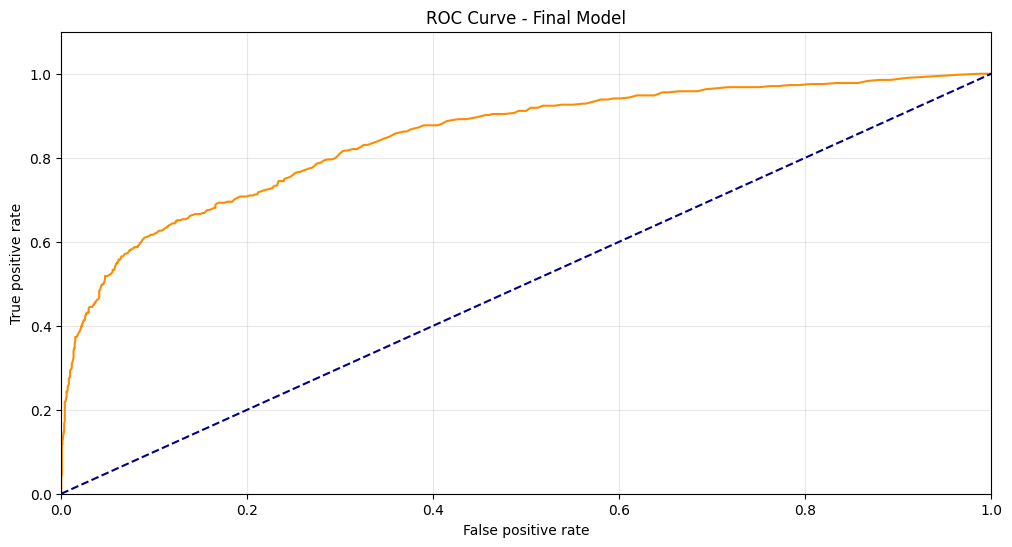

In [9]:
best_model = rf_random.best_estimator_

final_preds = best_model.predict(x_test)
final_probs = best_model.predict_proba(x_test)[:, 1]

final_f1 = f1_score(y_test, final_preds)
final_roc_auc = roc_auc_score(y_test, final_probs)

print("F1-Score FINAL:", final_f1)
print("AUC-ROC FINAL: ", final_roc_auc)

#Plotting the curve
fpr, tpr, threshold = roc_curve(y_test, final_probs)
plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {final_roc_auc:.4f})", color='darkorange')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.1])
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC Curve - Final Model")
plt.grid(alpha=0.3)
plt.show()

The final model achieves an **F1-score of 0.618** and an **AUC-ROC of 0.848** on the held-out test set — both exceeding the project's success criteria.

The ROC curve confirms the model's strong discriminatory power: an AUC of 0.848 means the model correctly ranks a randomly chosen churning customer above a randomly chosen retained customer in approximately 85% of cases — a meaningful signal for prioritizing retention efforts.

Comparing the two metrics reveals an important nuance: the AUC-ROC reflects the model's ranking ability across all thresholds, while the F1-score measures the specific balance between precision and recall at the default classification threshold. The F1-score, being more sensitive to performance on the minority class, provides a more operationally grounded view of how the model actually performs when deployed to identify at-risk customers.

---

## 8. Conclusion

This project addressed a critical and quantifiable business problem: **customer churn is costly, and preventing it requires predicting it in advance.**

The final model — a `RandomForestClassifier` trained on upsampled data and tuned via `RandomizedSearchCV` — delivers a **reliable, production-ready churn detection tool**. The key results are:

| Metric | Target | Result |
|---|---|---|
| F1-Score | ≥ 0.59 | **0.618** ✅ |
| AUC-ROC | Benchmark | **0.848** ✅ |

The full pipeline — from data cleaning and feature engineering, through class imbalance correction and hyperparameter optimization, to final evaluation — demonstrates the critical role each step plays in achieving a well-performing model:

- **Ignoring class imbalance** kept the model below the acceptable threshold. Addressing it with upsampling was the key inflection point.
- **Automated hyperparameter search** removed the guesswork and consistently improved on manual configurations.
- **Evaluating with F1-score** (not just accuracy) ensured the model is genuinely useful for the business objective — not just statistically convenient.

With this model, Beta Bank can now move from reactive customer management to **proactive retention**: identifying at-risk customers before they leave and directing loyalty efforts where they are most needed — reducing churn and lowering the cost of customer acquisition.